In [1]:
import pandas as pd

df = pd.read_csv("titanic_large.csv")
print(df.head())
print(df.info())

   PassengerId  Survived  Pclass    Name     Sex   Age  SibSp  Parch Ticket  \
0            1         0       2  Name_0    male  53.5      1      2   TKT0   
1            2         1       3  Name_1  female  30.0      2      0   TKT1   
2            3         0       3  Name_2  female  18.5      3      3   TKT2   
3            4         1       3  Name_3  female  31.7      3      2   TKT3   
4            5         1       1  Name_4    male  22.3      1      3   TKT4   

     Fare Cabin Embarked  
0    9.58    C0        S  
1  103.96    C1        S  
2   57.06    C2        S  
3  130.91    C3        C  
4  338.80    C4        S  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  10000 non-null  int64  
 1   Survived     10000 non-null  int64  
 2   Pclass       10000 non-null  int64  
 3   Name         10000 non-null  object 
 4 

In [3]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [4]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [5]:
df.fillna({
    'Age': df['Age'].median(),
    'Embarked': df['Embarked'].mode()[0]
}, inplace=True)

In [7]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [8]:
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch',
       'Fare', 'Embarked'],
      dtype='object')


In [10]:
df['Age']
df['Embarked']
df['Sex']

0         male
1       female
2       female
3       female
4         male
         ...  
9995    female
9996    female
9997    female
9998    female
9999      male
Name: Sex, Length: 10000, dtype: object

In [11]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [12]:
df.columns = df.columns.str.strip()

In [13]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df = pd.read_csv("titanic_large.csv")

print("Shape:", df.shape)
print(df.head())

Shape: (10000, 12)
   PassengerId  Survived  Pclass    Name     Sex   Age  SibSp  Parch Ticket  \
0            1         0       2  Name_0    male  53.5      1      2   TKT0   
1            2         1       3  Name_1  female  30.0      2      0   TKT1   
2            3         0       3  Name_2  female  18.5      3      3   TKT2   
3            4         1       3  Name_3  female  31.7      3      2   TKT3   
4            5         1       1  Name_4    male  22.3      1      3   TKT4   

     Fare Cabin Embarked  
0    9.58    C0        S  
1  103.96    C1        S  
2   57.06    C2        S  
3  130.91    C3        C  
4  338.80    C4        S  


In [16]:
# Remove spaces in column names
df.columns = df.columns.str.strip()

# Fill missing values (NO warning now)
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [17]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

In [18]:
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch',
            'Fare', 'Embarked', 'FamilySize', 'IsAlone']

X = df[features]
y = df['Survived']

In [19]:
categorical_features = ['Sex', 'Embarked']
numerical_features = ['Pclass', 'Age', 'SibSp',
                      'Parch', 'Fare', 'FamilySize', 'IsAlone']

In [20]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ]
)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [22]:
models = {
    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(max_iter=1000))
    ]),
    
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(n_estimators=100, random_state=42))
    ])
}

In [23]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results[name] = (acc, f1)
    
    print(f"\n{name}")
    print("Accuracy:", acc)
    print("F1 Score:", f1)
    print(classification_report(y_test, y_pred))


Logistic Regression
Accuracy: 0.746
F1 Score: 0.650137741046832
              precision    recall  f1-score   support

           0       0.81      0.80      0.80      1283
           1       0.64      0.66      0.65       717

    accuracy                           0.75      2000
   macro avg       0.72      0.73      0.73      2000
weighted avg       0.75      0.75      0.75      2000


Random Forest
Accuracy: 0.743
F1 Score: 0.6410614525139665
              precision    recall  f1-score   support

           0       0.80      0.80      0.80      1283
           1       0.64      0.64      0.64       717

    accuracy                           0.74      2000
   macro avg       0.72      0.72      0.72      2000
weighted avg       0.74      0.74      0.74      2000



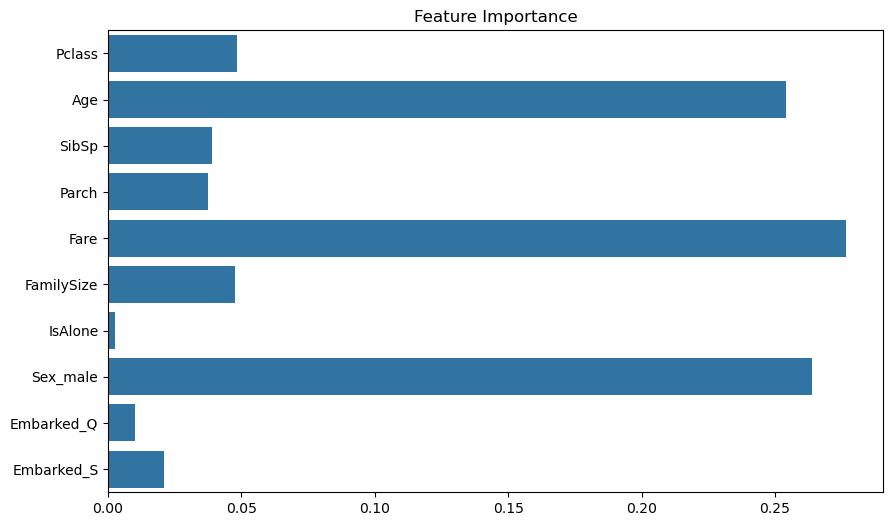

In [24]:
rf_model = models['Random Forest']

# Get feature names
feature_names = numerical_features + list(
    rf_model.named_steps['preprocessor']
    .named_transformers_['cat']
    .get_feature_names_out(categorical_features)
)

importances = rf_model.named_steps['model'].feature_importances_

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x=importances, y=feature_names)
plt.title("Feature Importance")
plt.show()